# Single Energy Deposit Forward Simulation

Simulates a single energy deposit — the impulse response of the TPC.
Useful for:
- Inspecting how recombination, diffusion, and drift shape a single charge cloud
- Comparing the response for different positions, angles, and physics parameters
- Validating the wire response kernel for each plane type (U / V / Y)

The simulation chain: dE → recombination → drift + diffusion → wire response kernel → ADC waveform.

In [1]:
# =============================================================================
# DEPOSIT PARAMETERS  (edit these)
# =============================================================================

# Global position in mm.  Volume 0 (East TPC): x in [-2160, 0], y/z in [-2160, 2160]
POSITION_MM = [-1080.0, 0.0, 0.0]   # centre of East TPC

DE_MEV  = 0.3     # energy deposit (MeV) — ~MIP in 3 mm LAr
DX_MM   = 3.0     # step length (mm)

# Track direction angles (radians).
# theta=0 → along drift axis (x); theta=pi/2, phi=0 → along Y wire direction.
import numpy as np
THETA = np.pi / 2   # polar angle from drift axis
PHI   = 0.0         # azimuthal angle in the YZ plane

# =============================================================================
# PHYSICS PARAMETERS  (Truth values used in the optimisation runs)
# =============================================================================

VELOCITY_CM_US  = 0.160       # drift velocity  [cm/μs]
LIFETIME_US     = 10_000.0    # electron lifetime [μs]  (use sim default for rest)

CONFIG_PATH = "config/cubic_wireplane_config.yaml"

In [2]:
import os, sys
cwd = os.getcwd()
# Handle both "Jupyter started from notebooks/" and "from repo root"
if os.path.isdir(os.path.join(cwd, 'tools')):
    repo_root = cwd
else:
    repo_root = os.path.abspath(os.path.join(cwd, '..'))
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print('Working dir:', os.getcwd())

Working dir: /home/gregor/JAXTPC


In [3]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import time

from tools.simulation import DetectorSimulator
from tools.geometry import generate_detector
from tools.loader import build_deposit_data

print('JAX devices:', jax.devices())

JAX devices: [CudaDevice(id=0)]


E0518 14:25:48.435225   70172 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )
E0518 14:25:48.448955   70036 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )


In [4]:
def pick_main_wire(sig, axis='wire'):
    """Return (idx, score): wire or time bin with the largest mean absolute signal.

    axis='wire' — average |sig| over time (axis=1), argmax over wires.
    axis='time' — average |sig| over wires (axis=0), argmax over time bins.
    """
    scores = np.abs(sig).mean(axis=1 if axis == 'wire' else 0)
    idx = int(np.argmax(scores))
    return idx, float(scores[idx])


def plot_vol_signals(signals, plane_names_flat, vol_indices_flat, vol_idx, cfg, title=""):
    """Plot wire-signal heatmaps for all planes in vol_idx.

    Works with any signals tuple from sim.forward() — no sim object needed.
    Returns the matplotlib Figure.
    """
    time_step_us = cfg.time_step_us
    vol_sigs = [
        (np.array(sig), name)
        for sig, name, vi in zip(signals, plane_names_flat, vol_indices_flat)
        if vi == vol_idx
    ]
    n_pl = len(vol_sigs)
    fig, axes = plt.subplots(1, n_pl, figsize=(5 * n_pl, 4), constrained_layout=True)
    if n_pl == 1:
        axes = [axes]

    for ax, (sig, name) in zip(axes, vol_sigs):
        main_wire, score = pick_main_wire(sig)

        col_has = np.any(sig != 0, axis=0)
        t_lo = max(0,            np.argmax(col_has) - 20)      if col_has.any() else 0
        t_hi = min(sig.shape[1], sig.shape[1] - np.argmax(col_has[::-1]) + 20) if col_has.any() else sig.shape[1]

        row_has = np.any(sig[:, t_lo:t_hi] != 0, axis=1)
        w_lo = max(0,            np.argmax(row_has) - 5)       if row_has.any() else 0
        w_hi = min(sig.shape[0], sig.shape[0] - np.argmax(row_has[::-1]) + 5) if row_has.any() else sig.shape[0]

        crop   = sig[w_lo:w_hi, t_lo:t_hi]
        t_axis = np.arange(t_lo, t_hi) * time_step_us
        w_axis = np.arange(w_lo, w_hi)
        vmax   = max(np.abs(crop).max(), 1.0)

        im = ax.imshow(
            crop, aspect='auto', origin='lower',
            extent=[t_axis[0], t_axis[-1], w_axis[0], w_axis[-1]],
            cmap='RdBu_r', vmin=-vmax, vmax=vmax,
        )
        ax.axhline(main_wire, color='k', lw=0.8, ls='--')
        ax.set_title(f'Plane {name}  (Vol {vol_idx}) — main wire {main_wire}')
        ax.set_xlabel('Time [μs]')
        ax.set_ylabel('Wire index')
        plt.colorbar(im, ax=ax, label='Electrons')

    if title:
        fig.suptitle(title, fontsize=10)
    plt.show()
    return fig


def plot_main_wire_traces(signals, plane_names_flat, vol_indices_flat, vol_idx, cfg,
                           trim_frac=0.025, title=""):
    """Plot V(t) for the main wire of each plane in vol_idx.

    Finds the time of peak combined |signal| across all planes, then shows a
    symmetric window of trim_frac * N_time_bins on each side of that peak.
    Returns the matplotlib Figure.
    """
    time_step_us = cfg.time_step_us
    vol_sigs = [
        (np.array(sig), name)
        for sig, name, vi in zip(signals, plane_names_flat, vol_indices_flat)
        if vi == vol_idx
    ]

    traces, main_wires, names = [], [], []
    for sig, name in vol_sigs:
        mw, _ = pick_main_wire(sig)
        traces.append(sig[mw, :])
        main_wires.append(mw)
        names.append(name)

    combined = sum(np.abs(tr) for tr in traces)
    t_peak = int(np.argmax(combined))
    half   = max(1, int(trim_frac * len(combined)))
    t_lo   = max(0, t_peak - half)
    t_hi   = min(len(combined), t_peak + half + 1)

    t_axis = np.arange(t_lo, t_hi) * time_step_us

    n_pl = len(vol_sigs)
    fig, axes = plt.subplots(1, n_pl, figsize=(5 * n_pl, 3), constrained_layout=True)
    if n_pl == 1:
        axes = [axes]

    for ax, trace, mw, name in zip(axes, traces, main_wires, names):
        ax.plot(t_axis, trace[t_lo:t_hi])
        ax.axhline(0, color='k', lw=0.5, ls=':')
        ax.set_title(f'Plane {name} — wire {mw}')
        ax.set_xlabel('Time [μs]')
        ax.set_ylabel('Signal [e⁻]')

    if title:
        fig.suptitle(title, fontsize=10)
    plt.show()
    return fig

In [5]:
# Build detector and simulator.
# differentiable=True with n_segments=16 gives a tiny total_pad → fast JIT compile.
detector_config = generate_detector(CONFIG_PATH)

N_SEGMENTS = 16   # total_pad = n_segments; must be >= number of deposits

sim = DetectorSimulator(
    detector_config,
    differentiable=True,
    n_segments=N_SEGMENTS,
    use_bucketed=True,
    max_active_buckets=200,
    include_noise=False,
    include_electronics=False,
    include_track_hits=False,
    include_digitize=False,
)

print('\nWarming up JIT...')
t0 = time.time()
sim.warm_up()
print(f'Done ({time.time()-t0:.1f} s)')

--- Creating DetectorSimulator ---
   Extracting parameters...
Calculated max diffusion sigmas:
  Transverse (cm): 0.1800
  Longitudinal (us): 0.8714
  Transverse (unitless): 0.6000
  Longitudinal (unitless): 1.7428
Max drift time (us): 1350.00 (max_drift_cm=216.0 cm, drift_velocity=0.160 cm/us)
Calculated max diffusion sigmas:
  Transverse (cm): 0.1800
  Longitudinal (us): 0.8714
  Transverse (unitless): 0.6000
  Longitudinal (unitless): 1.7428
Max drift time (us): 1350.00 (max_drift_cm=216.0 cm, drift_velocity=0.160 cm/us)


   Loading response kernels...
Calculated max diffusion sigmas:
  Transverse (cm): 0.1800
  Longitudinal (us): 0.8714
  Transverse (unitless): 0.6000
  Longitudinal (unitless): 1.7428
Max drift time (us): 1350.00 (max_drift_cm=216.0 cm, drift_velocity=0.160 cm/us)


   Space charge effects: DISABLED
   Recombination model: emb
   Config: total_pad=16, response_chunk=16, num_s=16, K_wire=2, K_time=6
   Track labeling: DISABLED
   Readout: wire
   Volumes: 2 (iterate=scan)
--- DetectorSimulator Ready ---

Warming up JIT...
Triggering JIT compilation...


JIT compilation finished (total_pad=16, iterate=scan).
Done (5.1 s)


In [6]:
# Physics parameters: start from the simulator defaults, override velocity + lifetime.
params = sim.default_sim_params._replace(
    velocity_cm_us = jnp.array(VELOCITY_CM_US),
    lifetime_us    = jnp.array(LIFETIME_US),
)

print('SimParams in use:')
print(f'  velocity_cm_us  = {float(params.velocity_cm_us):.4f}')
print(f'  lifetime_us     = {float(params.lifetime_us):.1f}')
rp = params.recomb_params
print(f'  recomb model    = {sim.recomb_model}')
print(f'  alpha           = {float(rp.alpha):.4f}')

SimParams in use:
  velocity_cm_us  = 0.1600
  lifetime_us     = 10000.0
  recomb model    = emb
  alpha           = 0.9040


In [7]:
# Build a single deposit.
positions_mm = np.array([POSITION_MM], dtype=np.float32)   # (1, 3)
de           = np.array([DE_MEV],       dtype=np.float32)  # (1,)
dx           = np.array([DX_MM],        dtype=np.float32)  # (1,)
theta        = np.array([THETA],        dtype=np.float32)
phi          = np.array([PHI],          dtype=np.float32)

deposits = build_deposit_data(
    positions_mm, de, dx, sim.config,
    theta=theta, phi=phi,
)

for vi, vol in enumerate(deposits.volumes):
    print(f'Volume {vi}: n_actual={vol.n_actual}')

Volume 0: n_actual=1
Volume 1: n_actual=0


In [8]:
# Quick physics sanity-check before running the full sim.
cfg = sim.config
pos_cm = np.array(POSITION_MM) / 10.0
x_cm = pos_cm[0]

# Determine which volume the deposit falls in.
for vi in range(cfg.n_volumes):
    vol = cfg.volumes[vi]
    x_min, x_max = vol.ranges_cm[0]
    if x_min <= x_cm < x_max:
        vol_idx = vi
        x_anode = vol.x_anode_cm
        drift_dir = vol.drift_direction
        break

drift_dist_cm = abs(x_cm - x_anode)
drift_time_us = drift_dist_cm / VELOCITY_CM_US
attenuation   = np.exp(-drift_time_us / LIFETIME_US)

# Approximate electron yield (no field/angle correction for this estimate).
W_ion_eV      = 23.6
N_ions        = DE_MEV * 1e6 / W_ion_eV          # ions before recombination
# Rough Modified-Box estimate (R ~ 0.7 for MIP at 500 V/cm)
R_approx      = 0.7
N_e_before    = N_ions * R_approx
N_e_after     = N_e_before * attenuation

print(f'Deposit in Volume {vol_idx} (East={vol_idx==0})')
print(f'  Position         : x={x_cm:.1f} cm  y={pos_cm[1]:.1f} cm  z={pos_cm[2]:.1f} cm')
print(f'  Distance to anode: {drift_dist_cm:.1f} cm')
print(f'  Drift time       : {drift_time_us:.1f} μs')
print(f'  Attenuation      : {attenuation:.4f}')
print(f'  Ions created     : {N_ions:,.0f}  (W_ion={W_ion_eV} eV)')
print(f'  Electrons after recomb (~R={R_approx}): {N_e_before:,.0f}')
print(f'  Electrons after lifetime attenuation  : {N_e_after:,.0f}')

Deposit in Volume 0 (East=True)
  Position         : x=-108.0 cm  y=0.0 cm  z=0.0 cm
  Distance to anode: 108.0 cm
  Drift time       : 675.0 μs
  Attenuation      : 0.9347
  Ions created     : 12,712  (W_ion=23.6 eV)
  Electrons after recomb (~R=0.7): 8,898
  Electrons after lifetime attenuation  : 8,317


In [9]:
# Run forward simulation.
print('Running forward sim...')
t0 = time.time()
signals = sim.forward(params, deposits)
jax.block_until_ready(signals)
print(f'Done ({time.time()-t0:.3f} s)')

# signals is a flat tuple: one array per (volume, plane) in order.
# Shape of each: (n_wires, n_time_bins)
n_planes_per_vol = [cfg.volumes[v].n_planes for v in range(cfg.n_volumes)]
plane_names_flat = [name
                    for v in range(cfg.n_volumes)
                    for name in cfg.plane_names[v]]
vol_indices_flat  = [v
                     for v in range(cfg.n_volumes)
                     for _ in range(n_planes_per_vol[v])]

for i, (sig, name, vi) in enumerate(zip(signals, plane_names_flat, vol_indices_flat)):
    arr = np.array(sig)
    print(f'  [{i}] Vol{vi} plane {name}: shape={arr.shape}  '
          f'max={arr.max():.2f}  min={arr.min():.2f}  '
          f'sum={arr.sum():.1f} e-')

Running forward sim...


Done (5.272 s)
  [0] Vol0 plane U: shape=(1969, 2701)  max=12.37  min=-17.56  sum=-71.8 e-
  [1] Vol0 plane V: shape=(1969, 2701)  max=14.31  min=-14.06  sum=-17.3 e-
  [2] Vol0 plane Y: shape=(1969, 2701)  max=44.84  min=-1.12  sum=421.6 e-
  [3] Vol1 plane U: shape=(1969, 2701)  max=0.00  min=0.00  sum=0.0 e-
  [4] Vol1 plane V: shape=(1969, 2701)  max=0.00  min=0.00  sum=0.0 e-
  [5] Vol1 plane Y: shape=(1969, 2701)  max=0.00  min=0.00  sum=0.0 e-


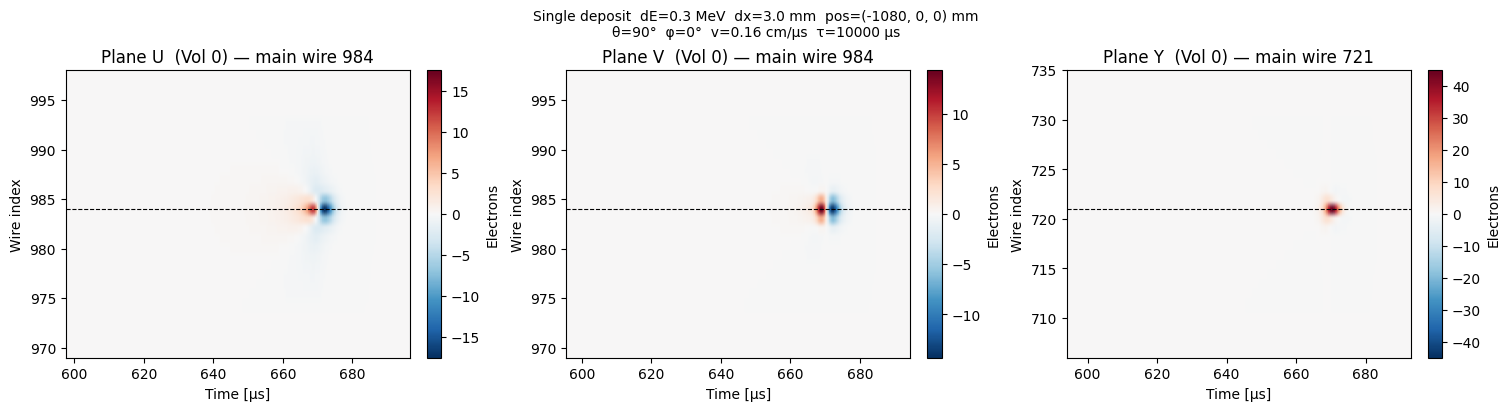

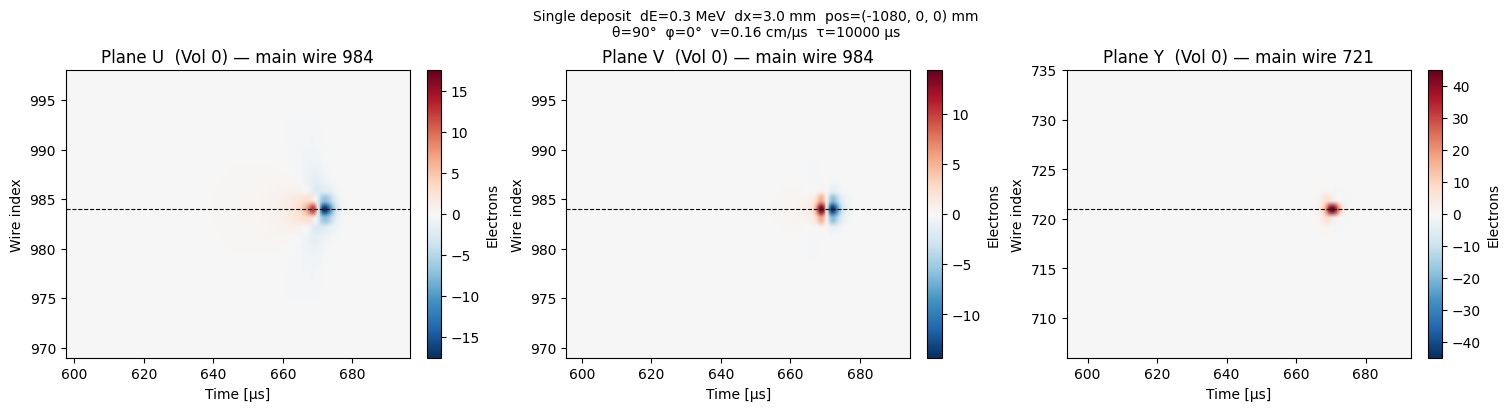

In [10]:
plot_vol_signals(
    signals, plane_names_flat, vol_indices_flat, vol_idx, cfg,
    title=(
        f'Single deposit  dE={DE_MEV} MeV  dx={DX_MM} mm  '
        f'pos=({POSITION_MM[0]:.0f}, {POSITION_MM[1]:.0f}, {POSITION_MM[2]:.0f}) mm\n'
        f'θ={np.degrees(THETA):.0f}°  φ={np.degrees(PHI):.0f}°  '
        f'v={VELOCITY_CM_US} cm/μs  τ={LIFETIME_US:.0f} μs'
    ),
)

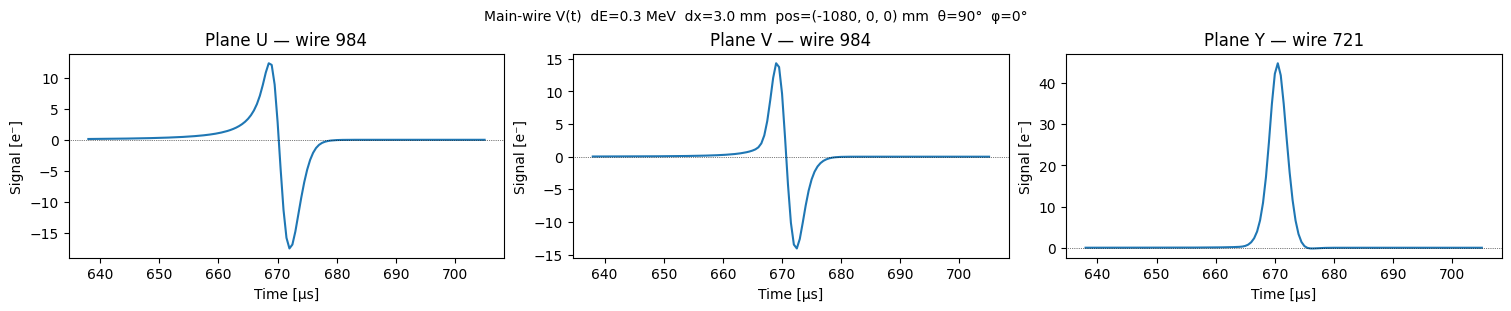

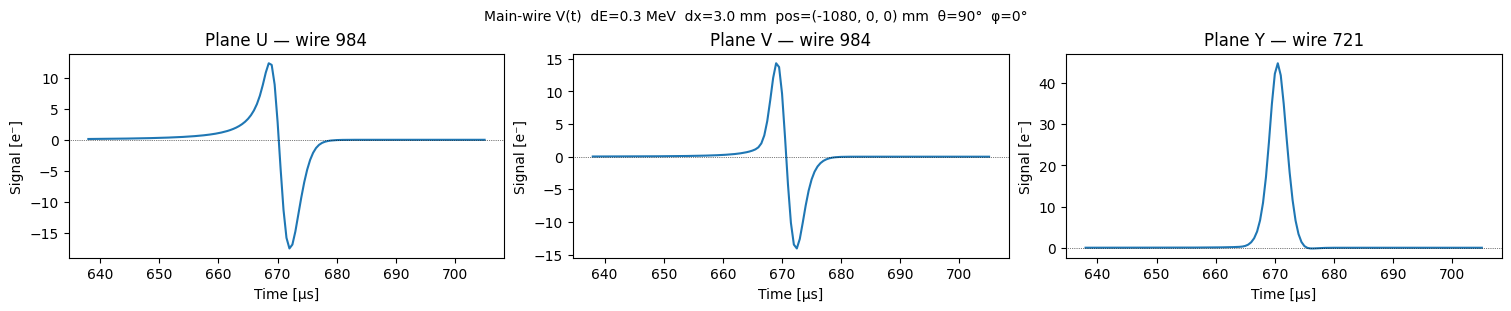

In [11]:
plot_main_wire_traces(
    signals, plane_names_flat, vol_indices_flat, vol_idx, cfg,
    trim_frac=0.025,
    title=(
        f'Main-wire V(t)  dE={DE_MEV} MeV  dx={DX_MM} mm  '
        f'pos=({POSITION_MM[0]:.0f}, {POSITION_MM[1]:.0f}, {POSITION_MM[2]:.0f}) mm  '
        f'θ={np.degrees(THETA):.0f}°  φ={np.degrees(PHI):.0f}°'
    ),
)

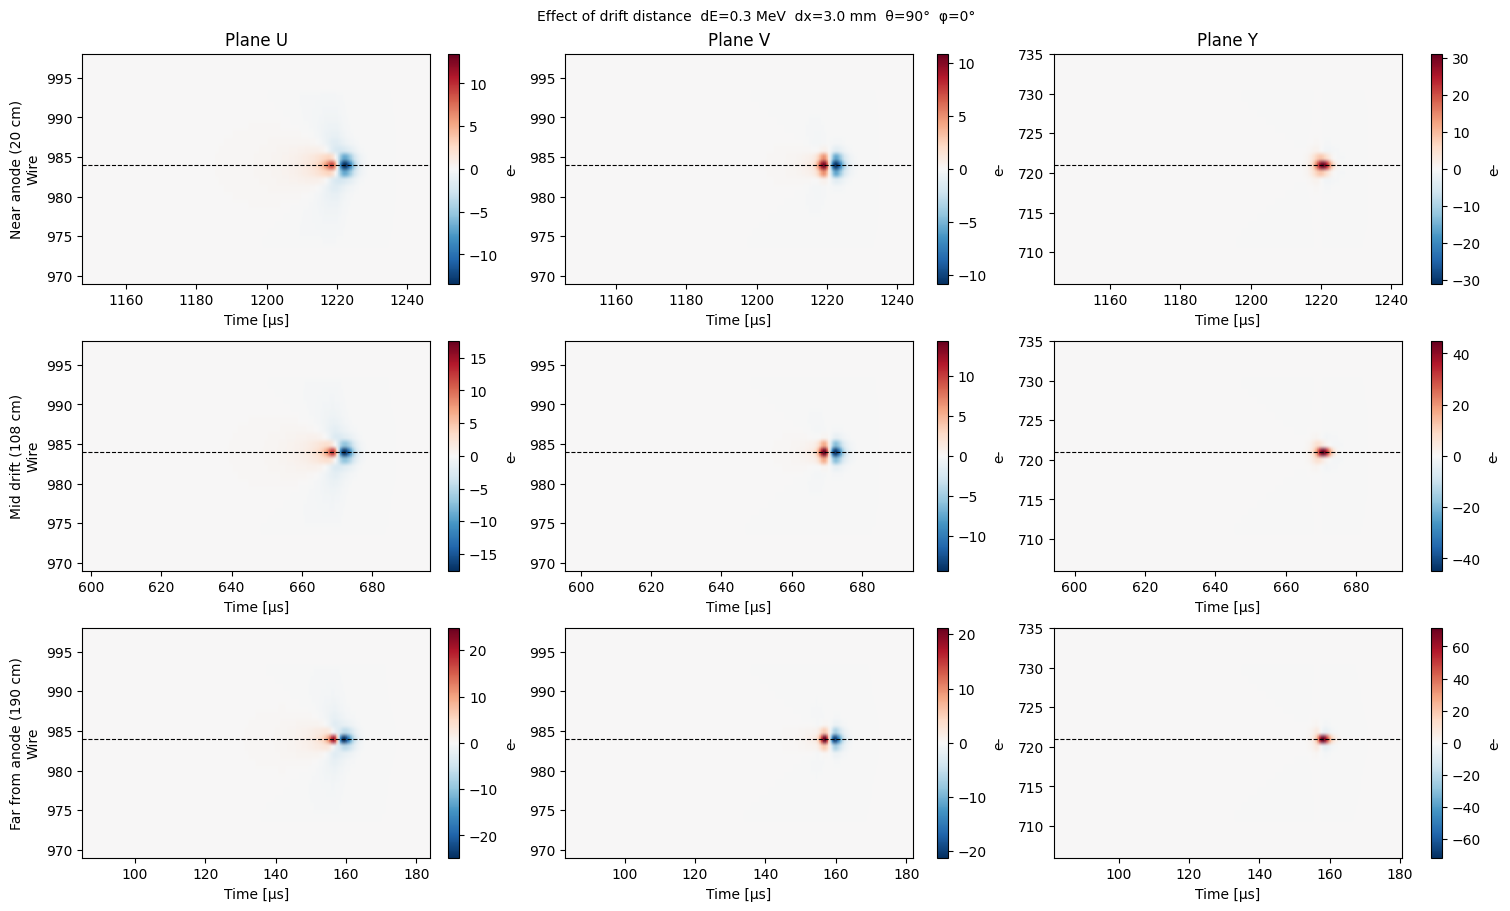

In [12]:
# ── Compare response for two different positions (e.g. near vs. far from anode) ──
positions_compare = [
    ('Near anode (20 cm)',       [-200.0,  0.0, 0.0]),
    ('Mid drift (108 cm)',       [-1080.0, 0.0, 0.0]),
    ('Far from anode (190 cm)', [-1900.0, 0.0, 0.0]),
]

n_pl = sum(1 for vi in vol_indices_flat if vi == vol_idx)
time_step_us = cfg.time_step_us

fig, axes = plt.subplots(len(positions_compare), n_pl,
                         figsize=(5 * n_pl, 3 * len(positions_compare)),
                         constrained_layout=True)

for row_idx, (label, pos_mm) in enumerate(positions_compare):
    dep = build_deposit_data(
        np.array([pos_mm], dtype=np.float32),
        np.array([DE_MEV],  dtype=np.float32),
        np.array([DX_MM],   dtype=np.float32),
        sim.config,
        theta=np.array([THETA], dtype=np.float32),
        phi=np.array([PHI],     dtype=np.float32),
    )
    sigs = sim.forward(params, dep)
    jax.block_until_ready(sigs)

    vol_sigs = [(np.array(s), nm)
                for s, nm, vi in zip(sigs, plane_names_flat, vol_indices_flat)
                if vi == vol_idx]

    for col_idx, (sig, name) in enumerate(vol_sigs):
        ax = axes[row_idx][col_idx] if len(positions_compare) > 1 else axes[col_idx]
        main_wire, _ = pick_main_wire(sig)

        col_has = np.any(sig != 0, axis=0)
        t_lo = max(0,            np.argmax(col_has) - 20)                          if col_has.any() else 0
        t_hi = min(sig.shape[1], sig.shape[1] - np.argmax(col_has[::-1]) + 20)    if col_has.any() else sig.shape[1]
        row_has = np.any(sig[:, t_lo:t_hi] != 0, axis=1)
        w_lo = max(0,            np.argmax(row_has) - 5)                           if row_has.any() else 0
        w_hi = min(sig.shape[0], sig.shape[0] - np.argmax(row_has[::-1]) + 5)     if row_has.any() else sig.shape[0]

        crop   = sig[w_lo:w_hi, t_lo:t_hi]
        t_axis = np.arange(t_lo, t_hi) * time_step_us
        w_axis = np.arange(w_lo, w_hi)
        vmax   = max(np.abs(crop).max(), 1.0)

        im = ax.imshow(crop, aspect='auto', origin='lower',
                       extent=[t_axis[0], t_axis[-1], w_axis[0], w_axis[-1]],
                       cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.axhline(main_wire, color='k', lw=0.8, ls='--')
        if row_idx == 0:
            ax.set_title(f'Plane {name}')
        if col_idx == 0:
            ax.set_ylabel(label + '\nWire')
        ax.set_xlabel('Time [μs]')
        plt.colorbar(im, ax=ax, label='e-')

fig.suptitle(
    f'Effect of drift distance  dE={DE_MEV} MeV  dx={DX_MM} mm  '
    f'θ={np.degrees(THETA):.0f}°  φ={np.degrees(PHI):.0f}°',
    fontsize=10,
)
plt.show()

In [13]:
# ── 3× transverse diffusion: run forward pass ────────────────────────────────
params_3x = params._replace(
    diffusion_trans_cm2_us=params.diffusion_trans_cm2_us * 9.0
)
print(f'D_T nominal={float(params.diffusion_trans_cm2_us):.2e} cm²/μs  '
      f'3x={float(params_3x.diffusion_trans_cm2_us):.2e} cm²/μs')

t0 = time.time()
signals_3x = sim.forward(params_3x, deposits)
jax.block_until_ready(signals_3x)
print(f'Done ({time.time()-t0:.3f} s)')

for s1, s3, name, vi in zip(signals, signals_3x, plane_names_flat, vol_indices_flat):
    a1, a3 = np.array(s1), np.array(s3)
    sq_diff = float(np.sum((a3 - a1) ** 2))
    print(f'  Vol{vi} plane {name}: sum_1x={a1.sum():.1f}  sum_3x={a3.sum():.1f}  sq_diff={sq_diff:.4f}')

D_T nominal=1.20e-05 cm²/μs  3x=1.08e-04 cm²/μs
Done (0.064 s)
  Vol0 plane U: sum_1x=-71.8  sum_3x=-70.9  sq_diff=682.1392
  Vol0 plane V: sum_1x=-17.3  sum_3x=-17.2  sq_diff=428.7941
  Vol0 plane Y: sum_1x=421.6  sum_3x=418.7  sq_diff=4926.9204
  Vol1 plane U: sum_1x=0.0  sum_3x=0.0  sq_diff=0.0000


  Vol1 plane V: sum_1x=0.0  sum_3x=0.0  sq_diff=0.0000
  Vol1 plane Y: sum_1x=0.0  sum_3x=0.0  sq_diff=0.0000


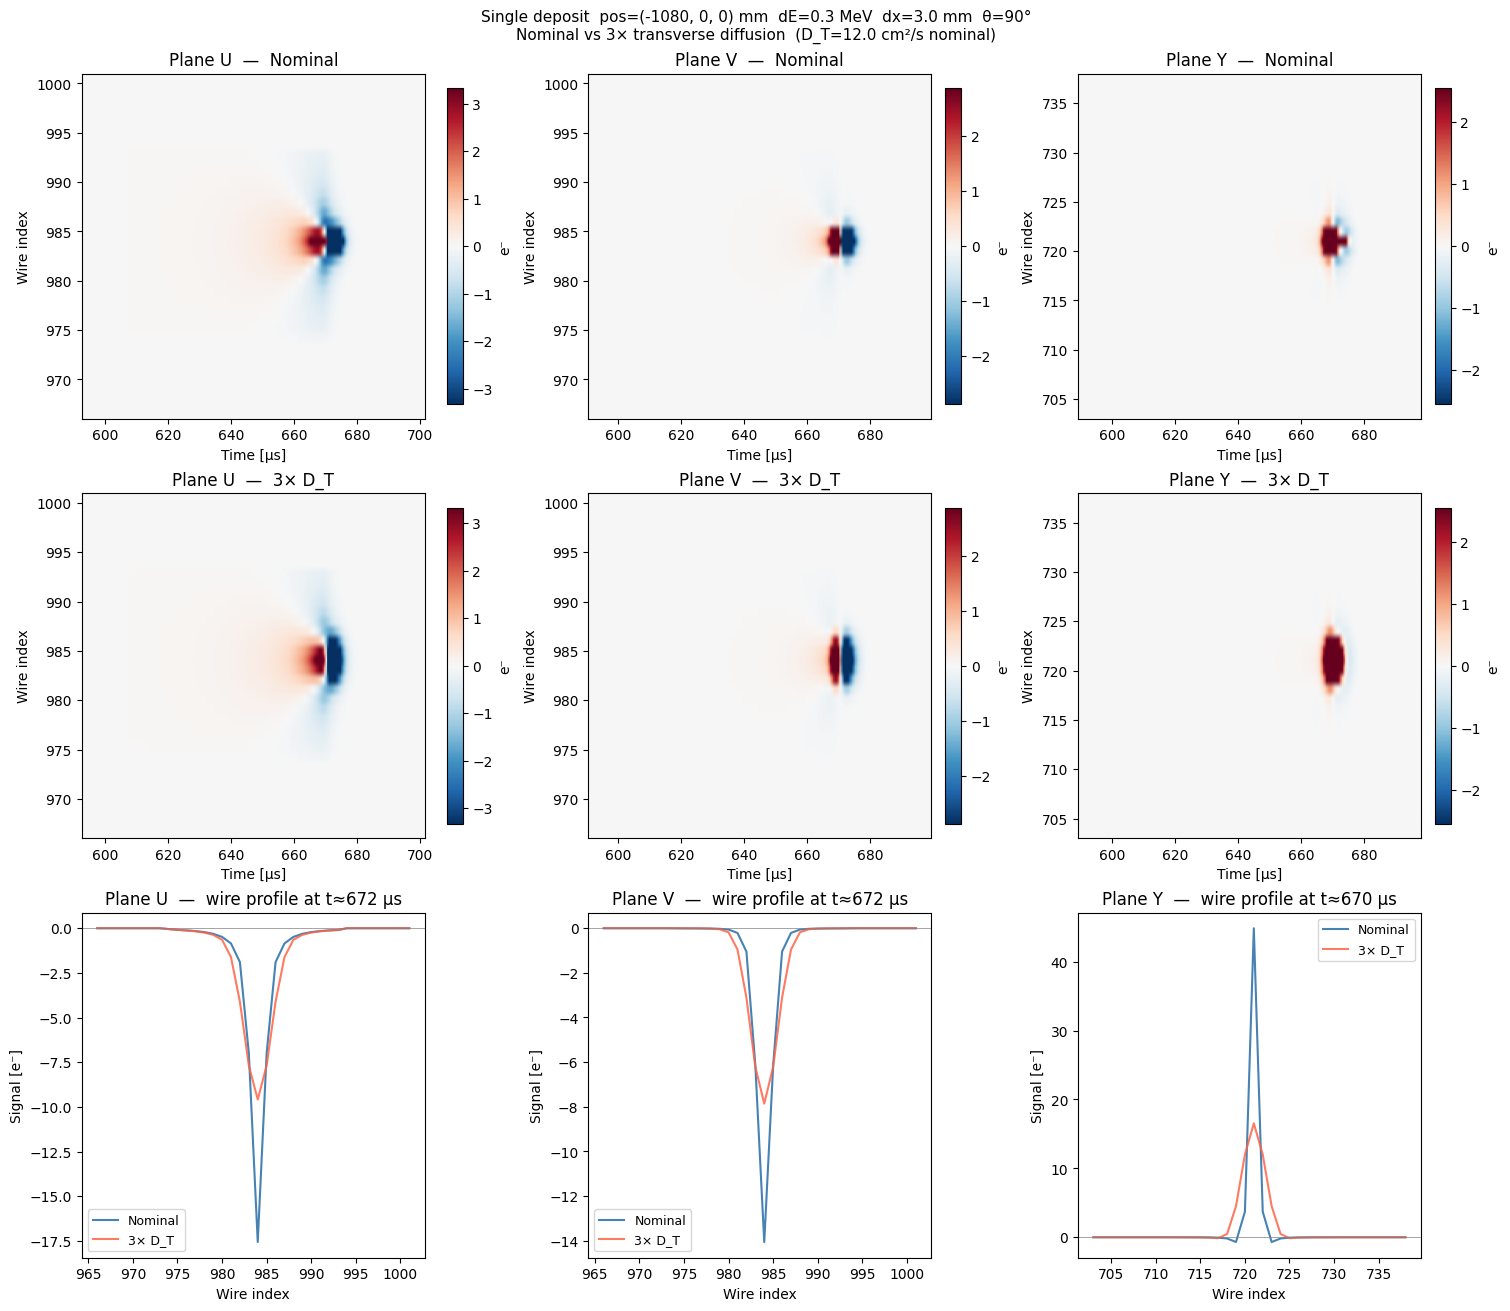

In [14]:
# ── Plot: nominal vs 3× transverse diffusion for the single deposit ──────────
n_pl         = sum(1 for vi in vol_indices_flat if vi == vol_idx)
time_step_us = cfg.time_step_us

vol_sigs_1x = [(np.array(s), nm) for s, nm, vi in zip(signals,    plane_names_flat, vol_indices_flat) if vi == vol_idx]
vol_sigs_3x = [(np.array(s), nm) for s, nm, vi in zip(signals_3x, plane_names_flat, vol_indices_flat) if vi == vol_idx]

fig, axes = plt.subplots(3, n_pl, figsize=(5 * n_pl, 13), constrained_layout=True)
if n_pl == 1:
    axes = axes[:, np.newaxis]

for col_idx, ((arr1, name), (arr3x, _)) in enumerate(zip(vol_sigs_1x, vol_sigs_3x)):
    # Bounding box from union of both signals
    combined = np.abs(arr1) + np.abs(arr3x)
    col_has = np.any(combined != 0, axis=0)
    row_has = np.any(combined != 0, axis=1)

    t_lo = int(max(0,             np.argmax(col_has) - 30))                          if col_has.any() else 0
    t_hi = int(min(arr1.shape[1], arr1.shape[1] - np.argmax(col_has[::-1]) + 30))   if col_has.any() else arr1.shape[1]
    w_lo = int(max(0,             np.argmax(row_has) - 8))                           if row_has.any() else 0
    w_hi = int(min(arr1.shape[0], arr1.shape[0] - np.argmax(row_has[::-1]) + 8))    if row_has.any() else arr1.shape[0]

    t_axis = np.arange(t_lo, t_hi) * time_step_us
    w_axis = np.arange(w_lo, w_hi)

    crop1  = arr1[w_lo:w_hi,  t_lo:t_hi]
    crop3x = arr3x[w_lo:w_hi, t_lo:t_hi]

    # Shared colour scale (99.5th percentile of both)
    vmax   = max(float(np.percentile(np.abs(np.concatenate([crop1.ravel(), crop3x.ravel()])), 99.5)), 1.0)
    has_neg = (arr1.min() < 0) or (arr3x.min() < 0)
    cmap   = 'RdBu_r' if has_neg else 'viridis'
    vmin   = -vmax if has_neg else 0.0
    extent = [t_axis[0], t_axis[-1], w_axis[0], w_axis[-1]]

    # Row 0: nominal
    ax = axes[0, col_idx]
    im = ax.imshow(crop1, aspect='auto', origin='lower', extent=extent,
                   cmap=cmap, vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='e⁻')
    ax.set_title(f'Plane {name}  —  Nominal')
    ax.set_xlabel('Time [μs]')
    ax.set_ylabel('Wire index')

    # Row 1: 3× diffusion (same colour scale)
    ax = axes[1, col_idx]
    im = ax.imshow(crop3x, aspect='auto', origin='lower', extent=extent,
                   cmap=cmap, vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='e⁻')
    ax.set_title(f'Plane {name}  —  3× D_T')
    ax.set_xlabel('Time [μs]')
    ax.set_ylabel('Wire index')

    # Row 2: wire profile at peak time, both curves overlaid
    peak_tick = int(np.argmax(np.abs(crop1).sum(axis=0))) + t_lo
    peak_us   = peak_tick * time_step_us
    ax = axes[2, col_idx]
    ax.plot(w_axis, arr1[w_lo:w_hi,  peak_tick], lw=1.5, color='steelblue', label='Nominal')
    ax.plot(w_axis, arr3x[w_lo:w_hi, peak_tick], lw=1.5, color='tomato',    label='3× D_T', alpha=0.85)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlabel('Wire index')
    ax.set_ylabel('Signal [e⁻]')
    ax.set_title(f'Plane {name}  —  wire profile at t≈{peak_us:.0f} μs')
    ax.legend(fontsize=9)

fig.suptitle(
    f'Single deposit  pos=({POSITION_MM[0]:.0f}, {POSITION_MM[1]:.0f}, {POSITION_MM[2]:.0f}) mm  '
    f'dE={DE_MEV} MeV  dx={DX_MM} mm  θ={np.degrees(THETA):.0f}°\n'
    f'Nominal vs 3× transverse diffusion  (D_T={float(params.diffusion_trans_cm2_us)*1e6:.1f} cm²/s nominal)',
    fontsize=11,
)
plt.show()